# AI 221 Assignment 4: Support Vector Classifier

<b>Description:</b> This notebook demonstrates classification of wine color using Support Vector Machines (SVM). Dataset used is the Wine Quality Dataset that can be found on https://archive.ics.uci.edu/dataset/186/wine+quality.
<br>
<br>
<b>Author:</b> Adrian Josele G. Quional
<br>
<b>Submitted to:</b> Dr. Jon Dewitt E. Dalisay
<br>
<b>Semester/Year:</b> 2nd Semester/2024-2025

## Imports

This section imports all needed Python libraries for the assignment.

In [1]:
# imports

# UCI repo
# Note: Before importing make sure to install first the UCI ML repo (if the dataset is not manually downloaded) using the command pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# for plotting
import seaborn as sns
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.pipeline import make_pipeline # for creation of ML pipeline
from sklearn.preprocessing import StandardScaler # for standardizing feature columns
from sklearn.model_selection import train_test_split # for data splitting
from sklearn.svm import SVC # for implementation of SVM for binary classification
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay # for evaluation of SVM
from sklearn.inspection import DecisionBoundaryDisplay # for inspection of decision boundaries

# for metrics summarization
import pandas as pd
import numpy as np

## Data Processing

This section processes the data for SVC implementation.

In [2]:
# fetching the wine quality dataset 
wine_quality = fetch_ucirepo(id=186) # alternatively: fetch_ucirepo(name='Wine Quality')

# saving the original (all features and target) data (as a pandas DataFrame) 
wine_quality_df = wine_quality.data.original

display(wine_quality_df)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


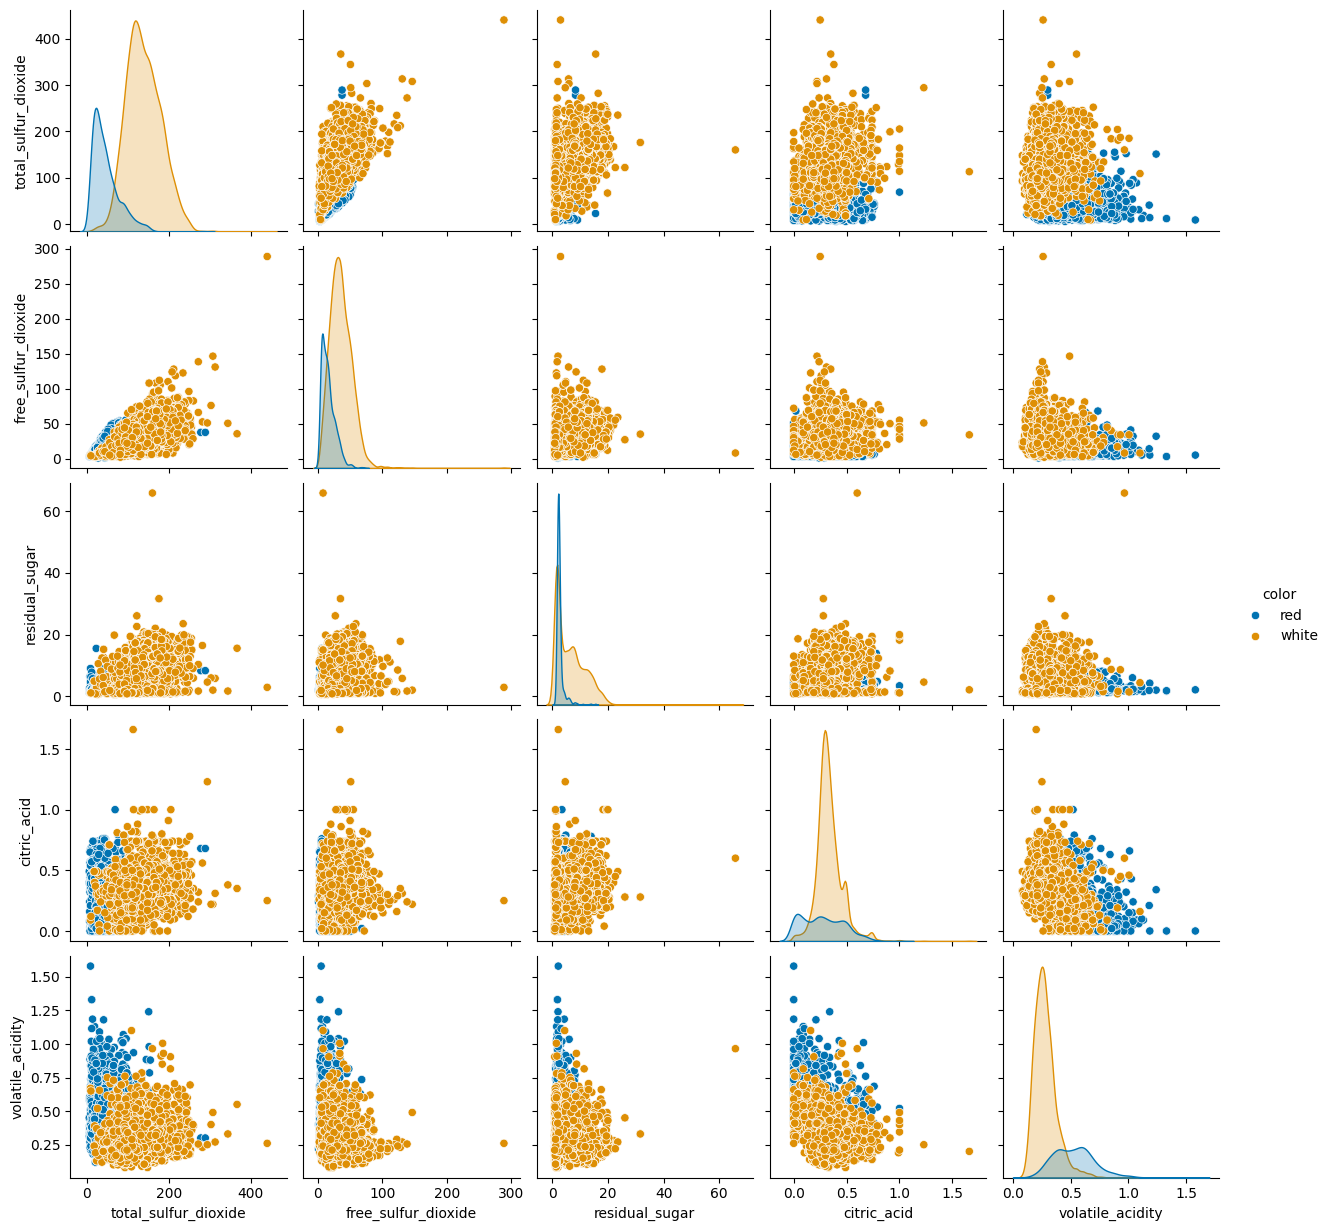

In [3]:
# creating a pairplot of selected features (selected by looking back at the EDA conducted for the dataset)
sns.pairplot(data=wine_quality_df[["total_sulfur_dioxide", "free_sulfur_dioxide", "residual_sugar", "citric_acid", "volatile_acidity", "color"]], hue="color", 
             palette="colorblind")
plt.show()

Based on the pairplot, the pairs of features that can be used to effectively classify wine color are: 
* `volatile_acidity` and `total_sulfur_dioxide`
* `volatile_acidity` and `citric_acid`
* `volatile_acidity` and `residual_sugar`
* `volatile_acidity` and `free_sulfur_dioxide`

In [4]:
# isolating features by dropping target columns
X = wine_quality_df.drop(["quality", "color"], axis=1).to_numpy()

# getting only the target column
y = wine_quality_df["color"].map({"white": 0, "red": 1}).to_numpy().reshape((-1, 1))

# checking features and target arrays
print("Features array:")
print(X)
print()

print("Target array:")
print(y)

Features array:
[[ 7.4   0.7   0.   ...  3.51  0.56  9.4 ]
 [ 7.8   0.88  0.   ...  3.2   0.68  9.8 ]
 [ 7.8   0.76  0.04 ...  3.26  0.65  9.8 ]
 ...
 [ 6.5   0.24  0.19 ...  2.99  0.46  9.4 ]
 [ 5.5   0.29  0.3  ...  3.34  0.38 12.8 ]
 [ 6.    0.21  0.38 ...  3.26  0.32 11.8 ]]

Target array:
[[1]
 [1]
 [1]
 ...
 [0]
 [0]
 [0]]


In [5]:
# splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.70, random_state=6)

# checking shapes of X
print(f"X_train.shape: {X_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print()

# checking shapes of y
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape: {y_test.shape}")
print()

X_train.shape: (1949, 11)
X_test.shape: (4548, 11)

y_train.shape: (1949, 1)
y_test.shape: (4548, 1)



## SVC Implementation

This section implements different experiments to classify wine color using SVC.

### Experiment 1: Using only `volatile_acidity` and `total_sulfur_dioxide`

Kernel: linear
Training accuracy: 0.9533093894304772
Test accuracy: 0.9544854881266491 

Confusion Matrix:
[[3323   83]
 [ 124 1018]]


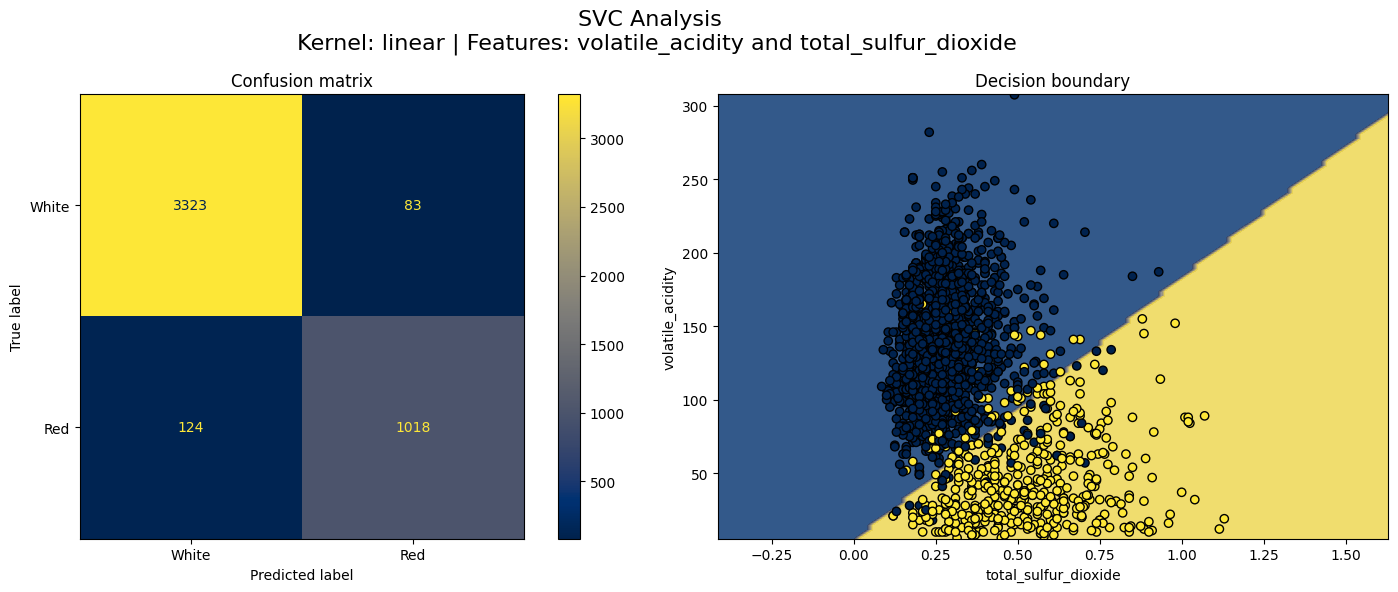

Classification report:
              precision    recall  f1-score   support

       white       0.96      0.98      0.97      3406
         red       0.92      0.89      0.91      1142

    accuracy                           0.95      4548
   macro avg       0.94      0.93      0.94      4548
weighted avg       0.95      0.95      0.95      4548


Kernel: rbf
Training accuracy: 0.9522832221652129
Test accuracy: 0.9540457343887423 

Confusion Matrix:
[[3309   97]
 [ 112 1030]]


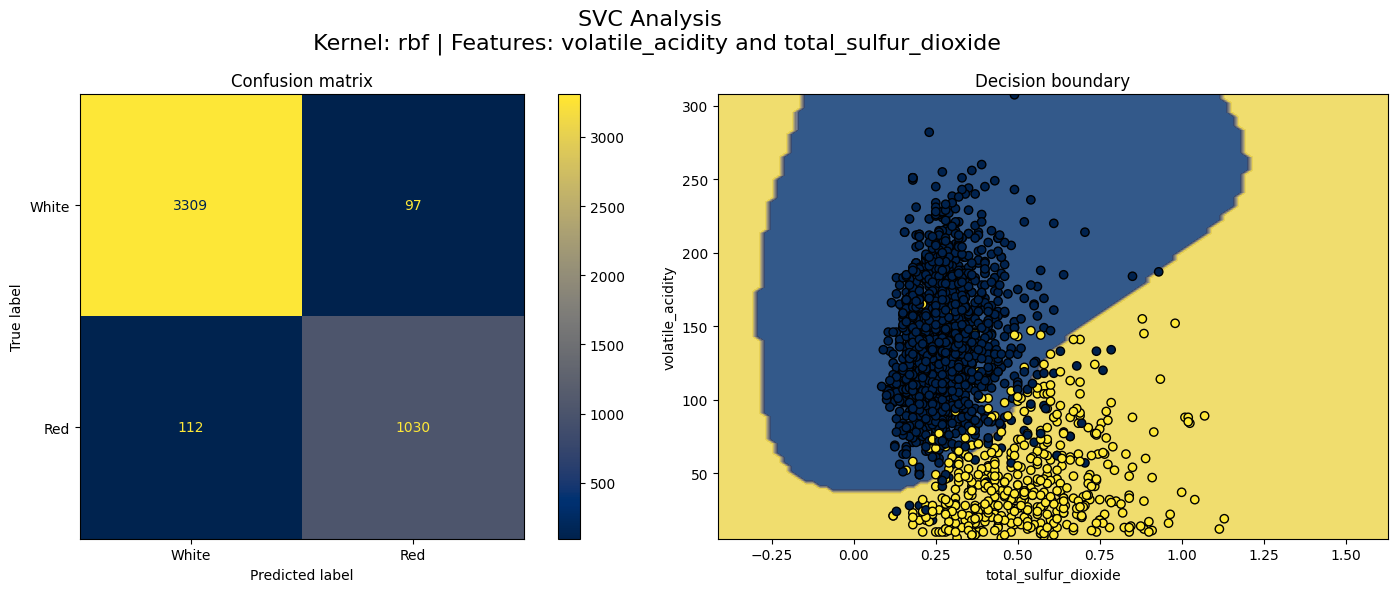

Classification report:
              precision    recall  f1-score   support

       white       0.97      0.97      0.97      3406
         red       0.91      0.90      0.91      1142

    accuracy                           0.95      4548
   macro avg       0.94      0.94      0.94      4548
weighted avg       0.95      0.95      0.95      4548


Kernel: poly
Training accuracy: 0.9507439712673166
Test accuracy: 0.9485488126649076 

Confusion Matrix:
[[3352   54]
 [ 180  962]]


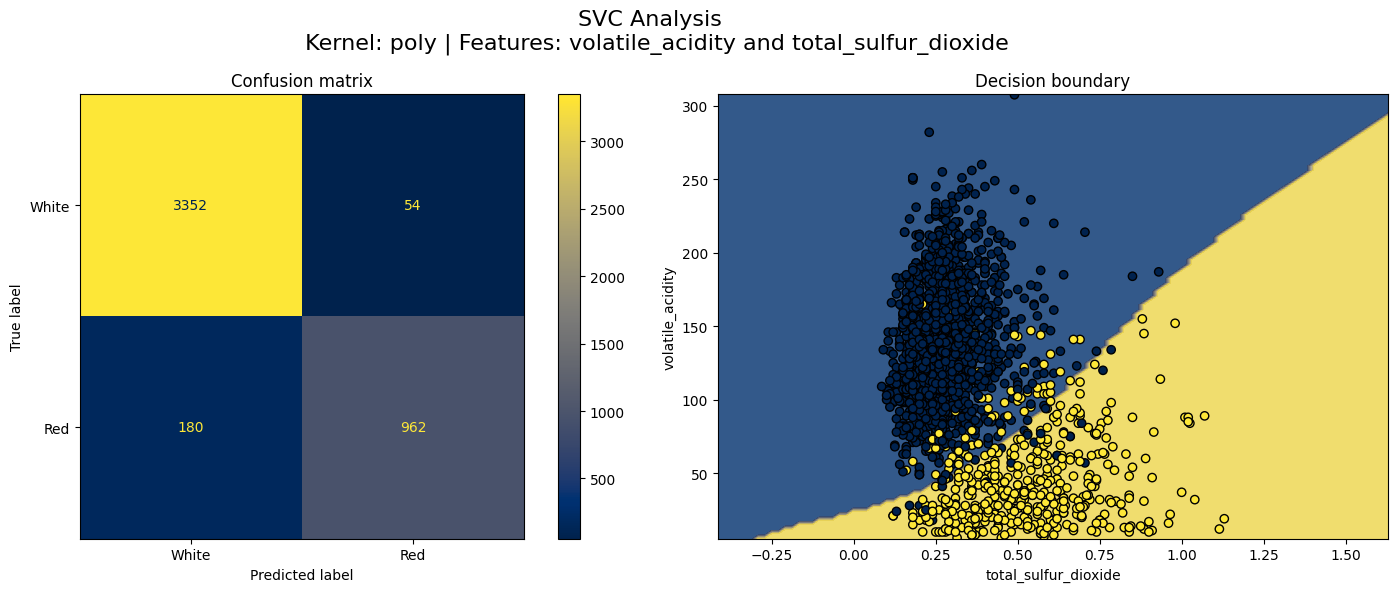

Classification report:
              precision    recall  f1-score   support

       white       0.95      0.98      0.97      3406
         red       0.95      0.84      0.89      1142

    accuracy                           0.95      4548
   macro avg       0.95      0.91      0.93      4548
weighted avg       0.95      0.95      0.95      4548


Kernel: sigmoid
Training accuracy: 0.8630066700872242
Test accuracy: 0.8634564643799473 

Confusion Matrix:
[[3055  351]
 [ 270  872]]


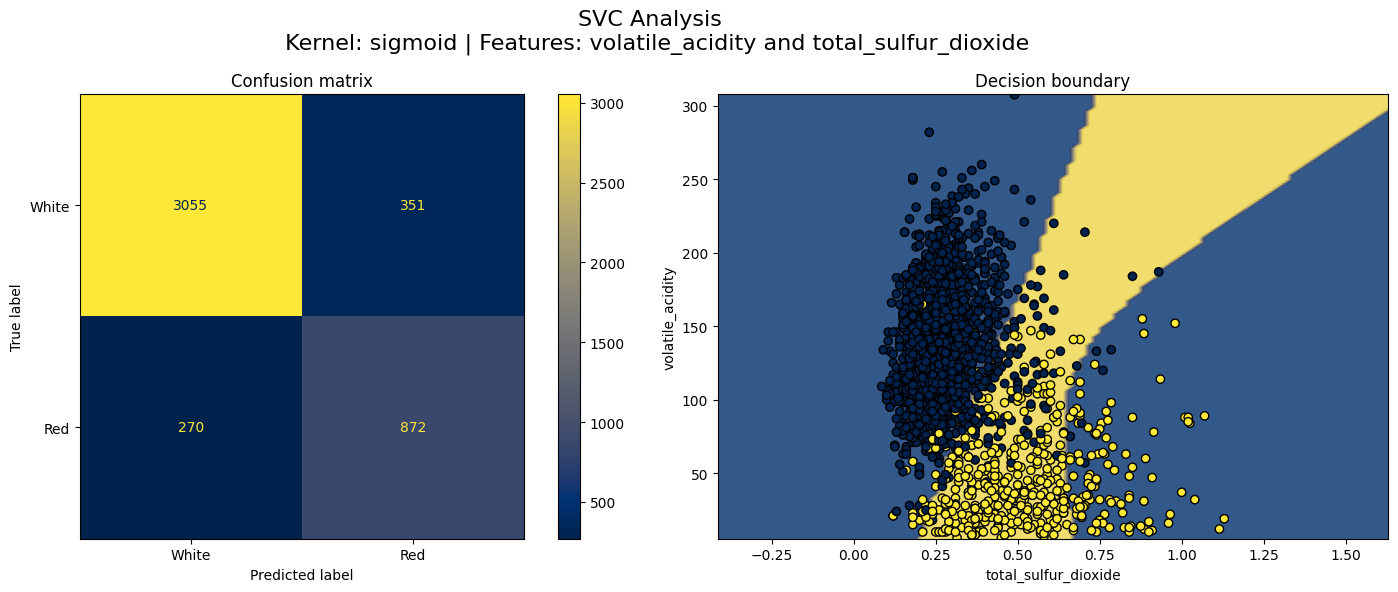

Classification report:
              precision    recall  f1-score   support

       white       0.92      0.90      0.91      3406
         red       0.71      0.76      0.74      1142

    accuracy                           0.86      4548
   macro avg       0.82      0.83      0.82      4548
weighted avg       0.87      0.86      0.86      4548


Accuracy summary:


,kernels,train_accuracies,test_accuracies
0,linear,0.953309,0.954485
1,rbf,0.952283,0.954046
2,poly,0.950744,0.948549
3,sigmoid,0.863007,0.863456



The best kernel based on test accuracy is: linear.


In [6]:
# lists to store accuracy metrics
kernels = []
train_accs = []
test_accs = []

# specifying feature columns to use (change this in the experiment)
col1 = 1 # volatile_acidity
col2 = 6 # total_sulfur_dioxide

feat1 = "volatile_acidity"
feat2 = "total_sulfur_dioxide"

# looping through all kernels to see which best classifies wine color
for kernel in ["linear", "rbf", "poly", "sigmoid"]:
    # SVC, selecting only volatile_acidity and total_sulfur_dioxide columns (columns 1 and 6, respectively)
    svc = make_pipeline(StandardScaler(), 
                        SVC(kernel=kernel)).fit(X_train[:, [col1, col2]], y_train.ravel())

    print(f"Kernel: {kernel}")

    # evaluating the classifier
    train_acc = svc.score(X_train[:, [col1, col2]], y_train.ravel())
    test_acc = svc.score(X_test[:, [col1, col2]], y_test.ravel())

    print(f"Training accuracy: {train_acc}")
    print(f"Test accuracy: {test_acc} ")
    print()

    # appending accuracies to their respective lists
    kernels.append(kernel)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # creating subplots (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))  

    # single title for both plots
    fig.suptitle(f"SVC Analysis \n Kernel: {kernel} | Features: {feat1} and {feat2}", fontsize=16)

    # showing the confusion matrix
    print("Confusion Matrix:")
    y_pred = svc.predict(X_test[:, [col1, col2]])
    print(confusion_matrix(y_test.ravel(), y_pred))
    ConfusionMatrixDisplay(confusion_matrix(y_test.ravel(), y_pred), display_labels = ["White", "Red"]).plot(ax=axes[0], cmap="cividis") 
    axes[0].set_title(f"Confusion matrix")
    DecisionBoundaryDisplay.from_estimator(svc, X_train[:, [col1, col2]], alpha=0.8, eps=0.5, response_method="predict", ax=axes[1], cmap="cividis")
    axes[1].scatter(X_train[:, col1], X_train[:, col2], c=y_train, edgecolors='k', cmap="cividis")
    axes[1].set_xlabel(f"{feat2}")
    axes[1].set_ylabel(f"{feat1}")
    axes[1].set_title(f"Decision boundary")

    plt.tight_layout()
    plt.show()

    print("Classification report:")
    print(classification_report(y_test.ravel(), y_pred, target_names={"white": 0, "red": 1}))

    print("================================================================================\n")

metrics_df = pd.DataFrame({
    "kernels" : kernels,
    "train_accuracies" : train_accs,
    "test_accuracies" : test_accs
})

print("Accuracy summary:")
display(metrics_df)

# finding the index of the maximum test accuracy
max_test_acc_ind = np.argmax(test_accs)

# getting the best kernel
best_kernel = kernels[max_test_acc_ind]

print(f"\nThe best kernel based on test accuracy is: {best_kernel}.")

Based on the experiment, if `volatile_acidity` and `total_sulfur_dioxide` are used as the features, the best classifier obtained is an SVC with linear kernel, achieving a test accuracy of 0.954485. With regards to other metrics, the classification report shows that, for an SVC with linear kernel, the classifier achieved the following:
* Precision of 0.96 for white wine and 0.92 for red wine
* Recall of 0.98 for white wine and 0.89 for red wine
* F1-score of 0.97 for white wine and 0.91 for red wine  

The slightly higher scores for white wine compared to red wine maybe attributed to the white wine having more examples than the red wine in the dataset. However, if these scores are compared to, say the sigmoid kernel, the linear kernel works definitely better since for the sigmoid kernel, there is a huge discrepancy in the precision, recall, and F1-scores between white and red wine classification.

### Experiment 2: Using only `volatile_acidity` and `citric_acid`

Kernel: linear
Training accuracy: 0.8691636736788096
Test accuracy: 0.8682937554969217 

Confusion Matrix:
[[3254  152]
 [ 447  695]]


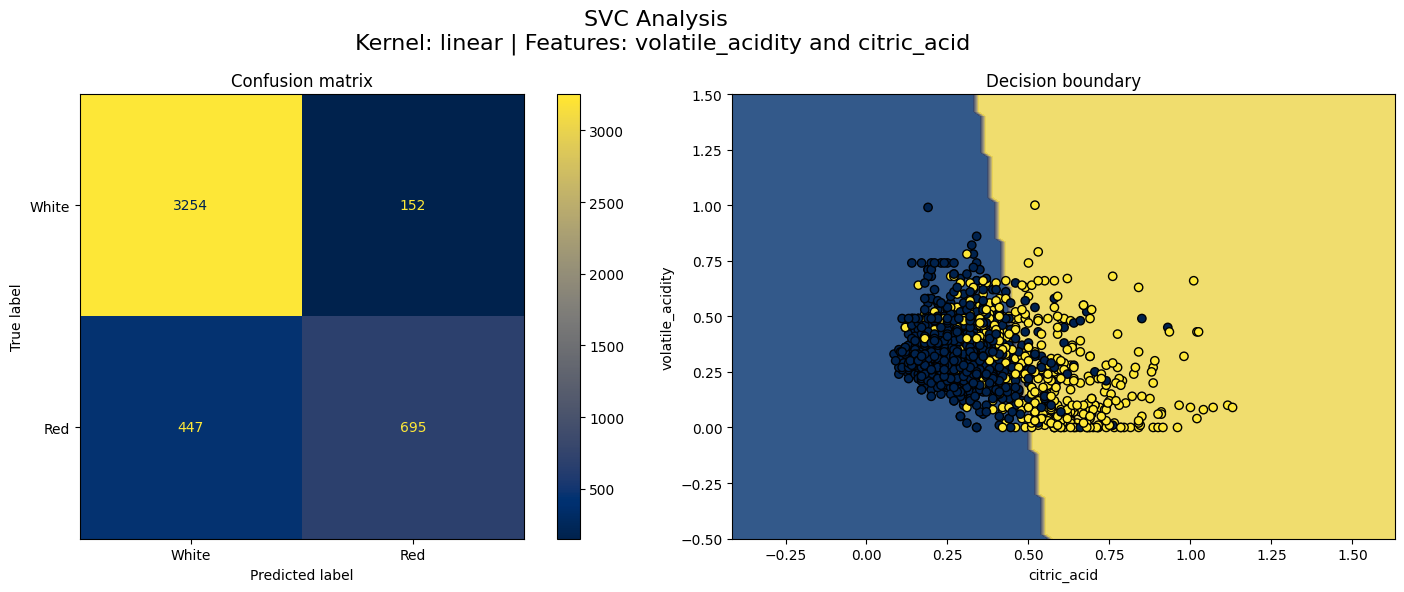

Classification report:
              precision    recall  f1-score   support

       white       0.88      0.96      0.92      3406
         red       0.82      0.61      0.70      1142

    accuracy                           0.87      4548
   macro avg       0.85      0.78      0.81      4548
weighted avg       0.86      0.87      0.86      4548


Kernel: rbf
Training accuracy: 0.8717290918419702
Test accuracy: 0.8663148636763413 

Confusion Matrix:
[[3248  158]
 [ 450  692]]


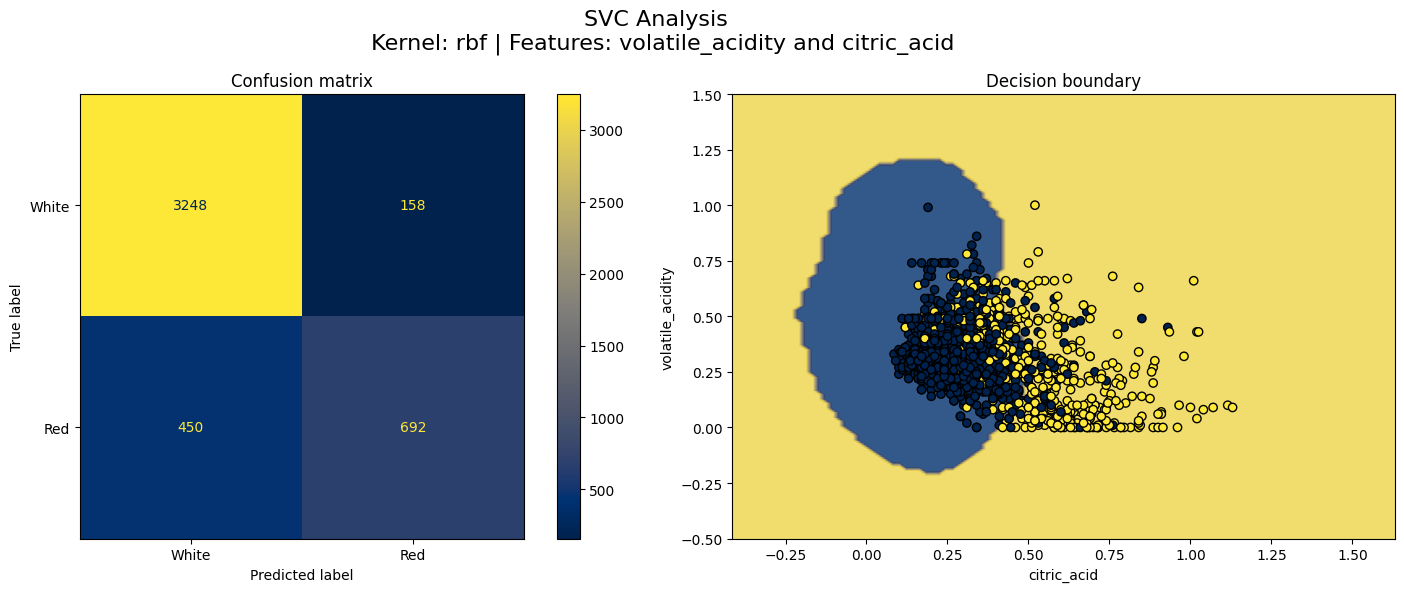

Classification report:
              precision    recall  f1-score   support

       white       0.88      0.95      0.91      3406
         red       0.81      0.61      0.69      1142

    accuracy                           0.87      4548
   macro avg       0.85      0.78      0.80      4548
weighted avg       0.86      0.87      0.86      4548


Kernel: poly
Training accuracy: 0.853771164699846
Test accuracy: 0.8421284080914688 

Confusion Matrix:
[[3323   83]
 [ 635  507]]


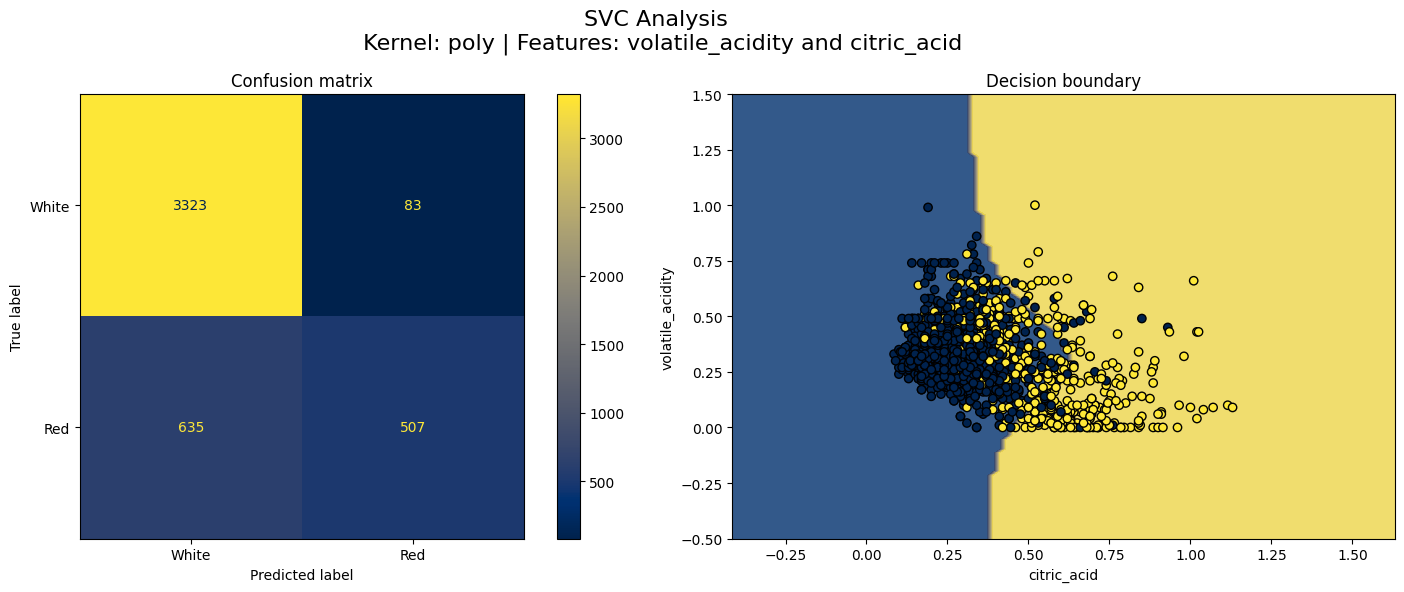

Classification report:
              precision    recall  f1-score   support

       white       0.84      0.98      0.90      3406
         red       0.86      0.44      0.59      1142

    accuracy                           0.84      4548
   macro avg       0.85      0.71      0.74      4548
weighted avg       0.84      0.84      0.82      4548


Kernel: sigmoid
Training accuracy: 0.7024114930733709
Test accuracy: 0.6952506596306068 

Confusion Matrix:
[[2719  687]
 [ 699  443]]


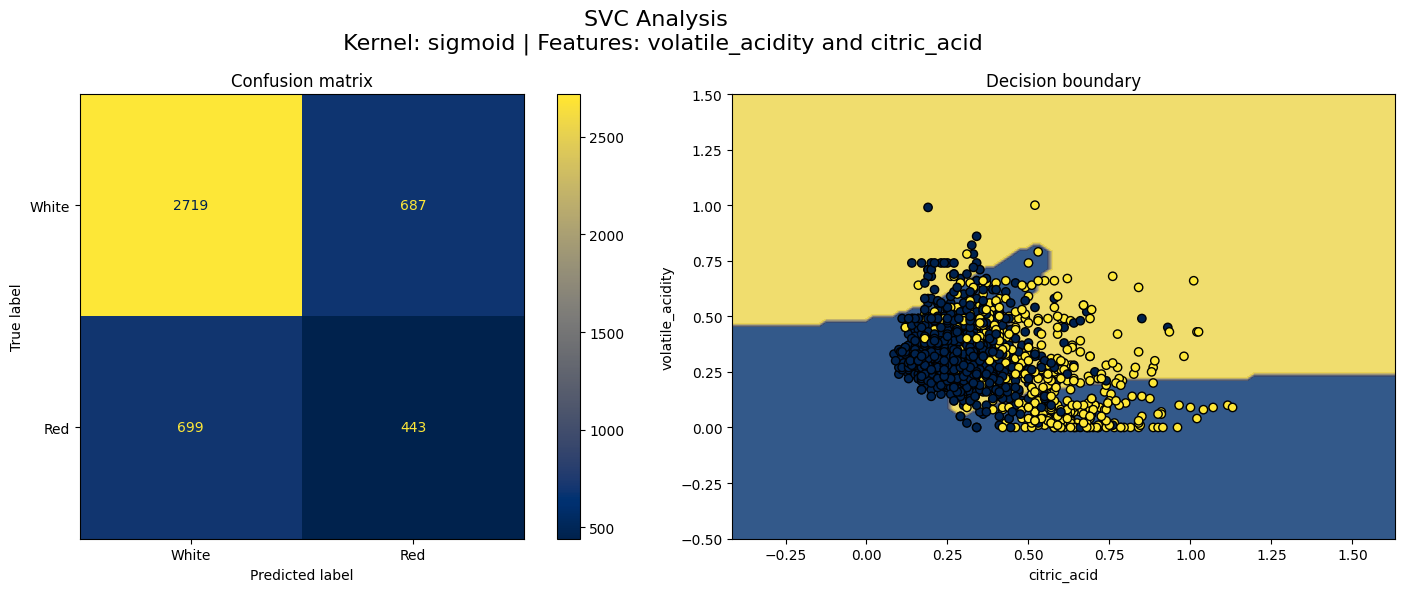

Classification report:
              precision    recall  f1-score   support

       white       0.80      0.80      0.80      3406
         red       0.39      0.39      0.39      1142

    accuracy                           0.70      4548
   macro avg       0.59      0.59      0.59      4548
weighted avg       0.69      0.70      0.69      4548


Accuracy summary:


,kernels,train_accuracies,test_accuracies
0,linear,0.869164,0.868294
1,rbf,0.871729,0.866315
2,poly,0.853771,0.842128
3,sigmoid,0.702411,0.695251



The best kernel based on test accuracy is: linear.


In [7]:
# lists to store accuracy metrics
kernels = []
train_accs = []
test_accs = []

# specifying feature columns to use (change this in the experiment)
col1 = 1 # volatile_acidity
col2 = 2 # citric_acid

feat1 = "volatile_acidity"
feat2 = "citric_acid"

# looping through all kernels to see which best classifies wine color
for kernel in ["linear", "rbf", "poly", "sigmoid"]:
    # SVC, selecting only volatile_acidity and citric_acid columns (columns 1 and 2, respectively)
    svc = make_pipeline(StandardScaler(), 
                        SVC(kernel=kernel)).fit(X_train[:, [col1, col2]], y_train.ravel())

    print(f"Kernel: {kernel}")

    # evaluating the classifier
    train_acc = svc.score(X_train[:, [col1, col2]], y_train.ravel())
    test_acc = svc.score(X_test[:, [col1, col2]], y_test.ravel())

    print(f"Training accuracy: {train_acc}")
    print(f"Test accuracy: {test_acc} ")
    print()

    # appending accuracies to their respective lists
    kernels.append(kernel)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # creating subplots (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))  

    # single title for both plots
    fig.suptitle(f"SVC Analysis \n Kernel: {kernel} | Features: {feat1} and {feat2}", fontsize=16)

    # showing the confusion matrix
    print("Confusion Matrix:")
    y_pred = svc.predict(X_test[:, [col1, col2]])
    print(confusion_matrix(y_test.ravel(), y_pred))
    ConfusionMatrixDisplay(confusion_matrix(y_test.ravel(), y_pred), display_labels = ["White", "Red"]).plot(ax=axes[0], cmap="cividis") 
    axes[0].set_title(f"Confusion matrix")
    DecisionBoundaryDisplay.from_estimator(svc, X_train[:, [col1, col2]], alpha=0.8, eps=0.5, response_method="predict", ax=axes[1], cmap="cividis")
    axes[1].scatter(X_train[:, col1], X_train[:, col2], c=y_train, edgecolors='k', cmap="cividis")
    axes[1].set_xlabel(f"{feat2}")
    axes[1].set_ylabel(f"{feat1}")
    axes[1].set_title(f"Decision boundary")

    plt.tight_layout()
    plt.show()

    print("Classification report:")
    print(classification_report(y_test.ravel(), y_pred, target_names={"white": 0, "red": 1}))

    print("================================================================================\n")

metrics_df = pd.DataFrame({
    "kernels" : kernels,
    "train_accuracies" : train_accs,
    "test_accuracies" : test_accs
})

print("Accuracy summary:")
display(metrics_df)

# finding the index of the maximum test accuracy
max_test_acc_ind = np.argmax(test_accs)

# getting the best kernel
best_kernel = kernels[max_test_acc_ind]

print(f"\nThe best kernel based on test accuracy is: {best_kernel}.")

Based on the experiment, the best SVC (created using `volatile_acidity` and `citric_acid` features) is still the one with a linear kernel, achieving a test accuracy of 0.868294. However, this accuracy is still lower than the best SVC created (also having a linear kernel) using `volatile_acidity` and `total_sulfur_dioxide` as the features. Furthermore, looking at the classification report for the SVC with linear kernel, the scores have the same behavior as before (that is, scores for white wine are slightly higher than those for red wine), but they are lower than the one created using `volatile_acidity` and `total_sulfur_dioxide` features. The following are the precision, recall, and F1-score from the classification report:
* Precision of 0.88 for white wine, 0.82 for red wine
* Recall of 0.96 for white wine, 0.61 for red wine
* F1-score of 0.92 for white wine, 0.70 for red wine

Based on these scores, the SVC (with linear kernel) created using `volatile_acidity` and `total_sulfur_dioxide` features is still better than the one created using `volatile_acidity` and `citric_acid` features. This shows that, perhaps, `volatile_acidity` and `citric_acid` are not the best features to use when classifying wine color. 

### Experiment 3: Using only `volatile_acidity` and `residual_sugar`

Kernel: linear
Training accuracy: 0.8891739353514623
Test accuracy: 0.8847845206684257 

Confusion Matrix:
[[3276  130]
 [ 394  748]]


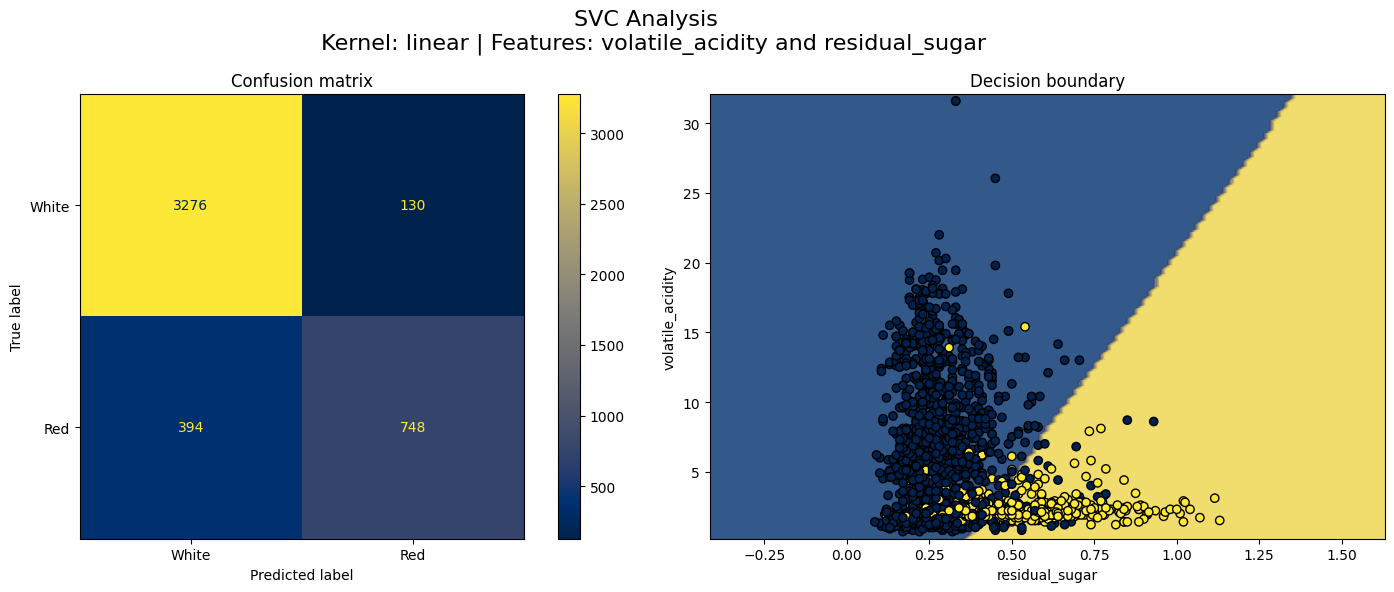

Classification report:
              precision    recall  f1-score   support

       white       0.89      0.96      0.93      3406
         red       0.85      0.65      0.74      1142

    accuracy                           0.88      4548
   macro avg       0.87      0.81      0.83      4548
weighted avg       0.88      0.88      0.88      4548


Kernel: rbf
Training accuracy: 0.896870189840944
Test accuracy: 0.8905013192612137 

Confusion Matrix:
[[3260  146]
 [ 352  790]]


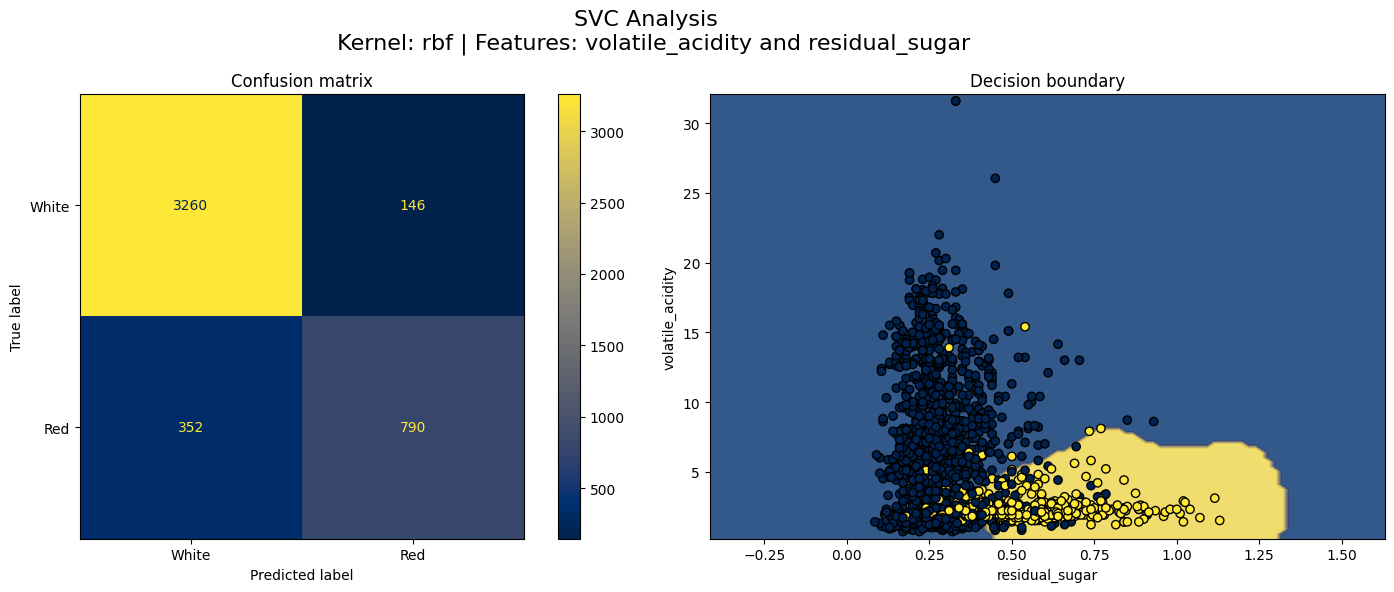

Classification report:
              precision    recall  f1-score   support

       white       0.90      0.96      0.93      3406
         red       0.84      0.69      0.76      1142

    accuracy                           0.89      4548
   macro avg       0.87      0.82      0.84      4548
weighted avg       0.89      0.89      0.89      4548


Kernel: poly
Training accuracy: 0.8814776808619805
Test accuracy: 0.8702726473175022 

Confusion Matrix:
[[3325   81]
 [ 509  633]]


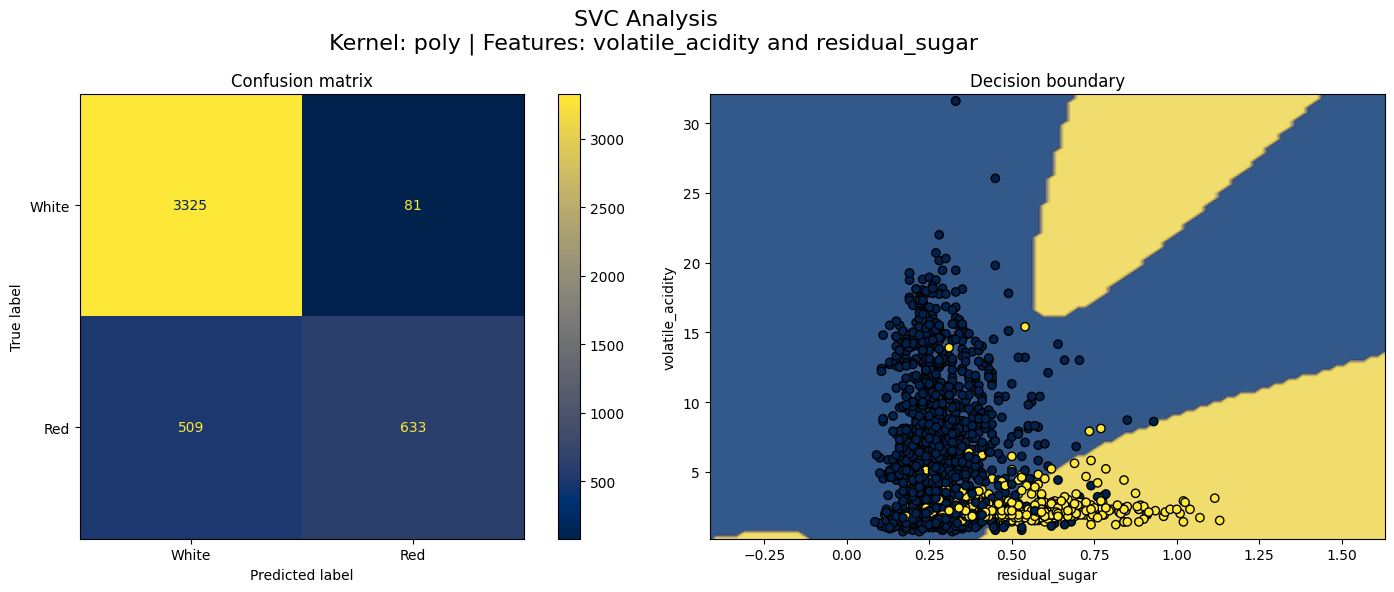

Classification report:
              precision    recall  f1-score   support

       white       0.87      0.98      0.92      3406
         red       0.89      0.55      0.68      1142

    accuracy                           0.87      4548
   macro avg       0.88      0.77      0.80      4548
weighted avg       0.87      0.87      0.86      4548


Kernel: sigmoid
Training accuracy: 0.7891226269881991
Test accuracy: 0.7974934036939314 

Confusion Matrix:
[[2944  462]
 [ 459  683]]


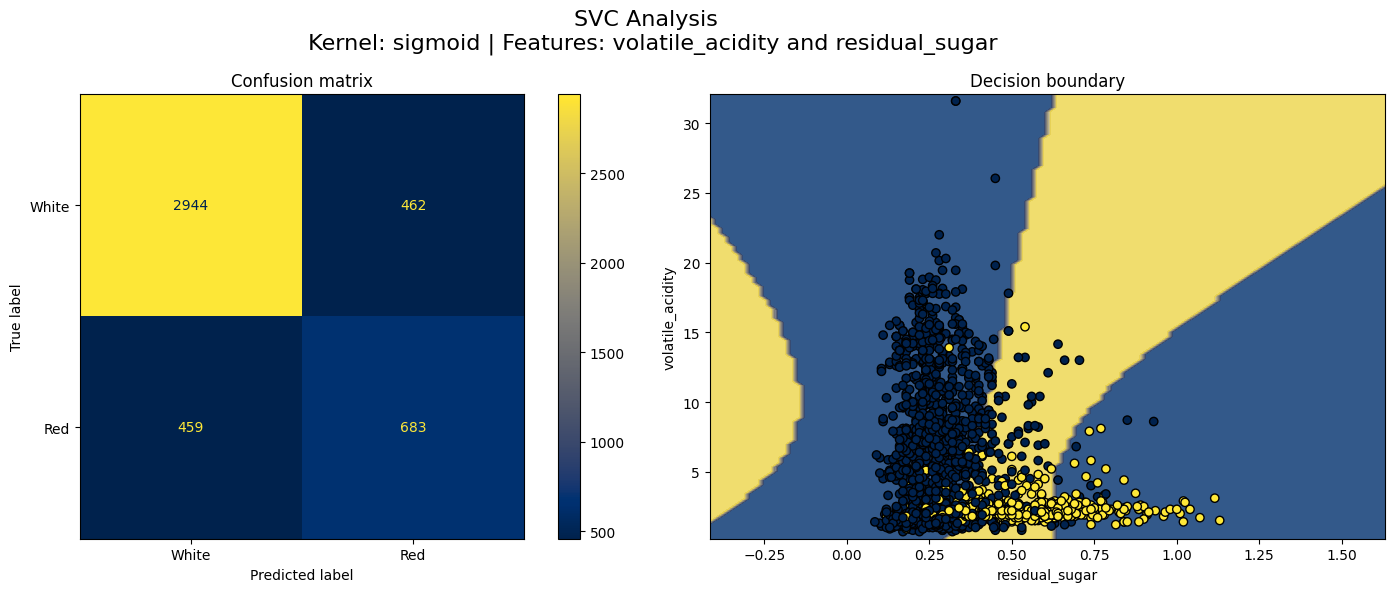

Classification report:
              precision    recall  f1-score   support

       white       0.87      0.86      0.86      3406
         red       0.60      0.60      0.60      1142

    accuracy                           0.80      4548
   macro avg       0.73      0.73      0.73      4548
weighted avg       0.80      0.80      0.80      4548


Accuracy summary:


,kernels,train_accuracies,test_accuracies
0,linear,0.889174,0.884785
1,rbf,0.896870,0.890501
2,poly,0.881478,0.870273
3,sigmoid,0.789123,0.797493



The best kernel based on test accuracy is: rbf.


In [8]:
# lists to store accuracy metrics
kernels = []
train_accs = []
test_accs = []

# specifying feature columns to use (change this in the experiment)
col1 = 1 # volatile_acidity
col2 = 3 # residual_sugar

feat1 = "volatile_acidity"
feat2 = "residual_sugar"

# looping through all kernels to see which best classifies wine color
for kernel in ["linear", "rbf", "poly", "sigmoid"]:
    # SVC, selecting only volatile_acidity and residual columns (columns 1 and 3, respectively)
    svc = make_pipeline(StandardScaler(), 
                        SVC(kernel=kernel)).fit(X_train[:, [col1, col2]], y_train.ravel())

    print(f"Kernel: {kernel}")

    # evaluating the classifier
    train_acc = svc.score(X_train[:, [col1, col2]], y_train.ravel())
    test_acc = svc.score(X_test[:, [col1, col2]], y_test.ravel())

    print(f"Training accuracy: {train_acc}")
    print(f"Test accuracy: {test_acc} ")
    print()

    # appending accuracies to their respective lists
    kernels.append(kernel)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # creating subplots (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))  

    # single title for both plots
    fig.suptitle(f"SVC Analysis \n Kernel: {kernel} | Features: {feat1} and {feat2}", fontsize=16)

    # showing the confusion matrix
    print("Confusion Matrix:")
    y_pred = svc.predict(X_test[:, [col1, col2]])
    print(confusion_matrix(y_test.ravel(), y_pred))
    ConfusionMatrixDisplay(confusion_matrix(y_test.ravel(), y_pred), display_labels = ["White", "Red"]).plot(ax=axes[0], cmap="cividis") 
    axes[0].set_title(f"Confusion matrix")
    DecisionBoundaryDisplay.from_estimator(svc, X_train[:, [col1, col2]], alpha=0.8, eps=0.5, response_method="predict", ax=axes[1], cmap="cividis")
    axes[1].scatter(X_train[:, col1], X_train[:, col2], c=y_train, edgecolors='k', cmap="cividis")
    axes[1].set_xlabel(f"{feat2}")
    axes[1].set_ylabel(f"{feat1}")
    axes[1].set_title(f"Decision boundary")

    plt.tight_layout()
    plt.show()

    print("Classification report:")
    print(classification_report(y_test.ravel(), y_pred, target_names={"white": 0, "red": 1}))

    print("================================================================================\n")

metrics_df = pd.DataFrame({
    "kernels" : kernels,
    "train_accuracies" : train_accs,
    "test_accuracies" : test_accs
})

print("Accuracy summary:")
display(metrics_df)

# finding the index of the maximum test accuracy
max_test_acc_ind = np.argmax(test_accs)

# getting the best kernel
best_kernel = kernels[max_test_acc_ind]

print(f"\nThe best kernel based on test accuracy is: {best_kernel}.")

Based on the experiment, the best SVC (created using `volatile_acidity` and `residual_sugar` features) is the one with an rbf kernel, departing from the previous experiments where the best SVC is the one with the linear kernel. For this experiment, the highest test accuracy achieved for the rbf kernel is 0.890501. Furthermore, the classification report shows the following scores for this SVC:
* Precision of 0.90 for white wine, 0.84 for red wine
* Recall of 0.96 for white wine, 0.69 for red wine
* F1-score of 0.93 for white wine, 0.76 for red wine

Based on these scores, the SVC (with rbf kernel) created using `volatile_acidity` and `residual_sugar` features is still not better than the first best SVC created; however, this is slightly better than the second best SVC created (`volatile_acidity` and `citric_acid` features). 

### Experiment 4: Using only `volatile_acidity` and `free_sulfur_dioxide`

Kernel: linear
Training accuracy: 0.8978963571062083
Test accuracy: 0.8887423043095867 

Confusion Matrix:
[[3236  170]
 [ 336  806]]


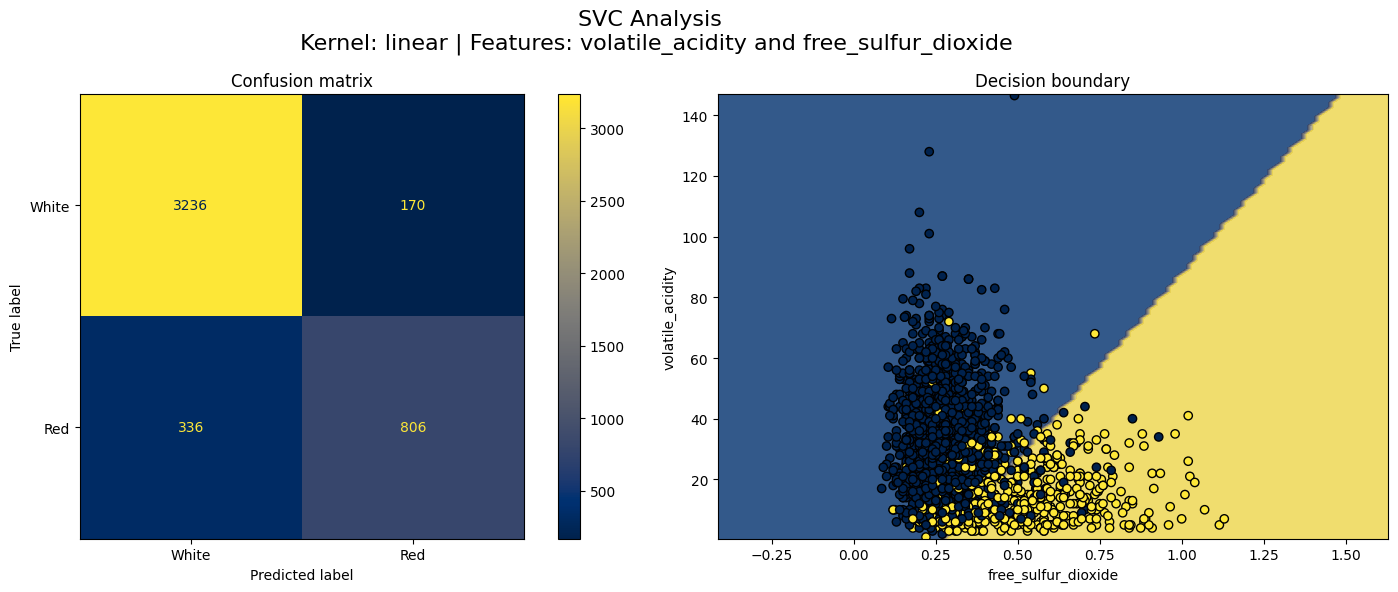

Classification report:
              precision    recall  f1-score   support

       white       0.91      0.95      0.93      3406
         red       0.83      0.71      0.76      1142

    accuracy                           0.89      4548
   macro avg       0.87      0.83      0.84      4548
weighted avg       0.89      0.89      0.89      4548


Kernel: rbf
Training accuracy: 0.8978963571062083
Test accuracy: 0.8880826737027264 

Confusion Matrix:
[[3218  188]
 [ 321  821]]


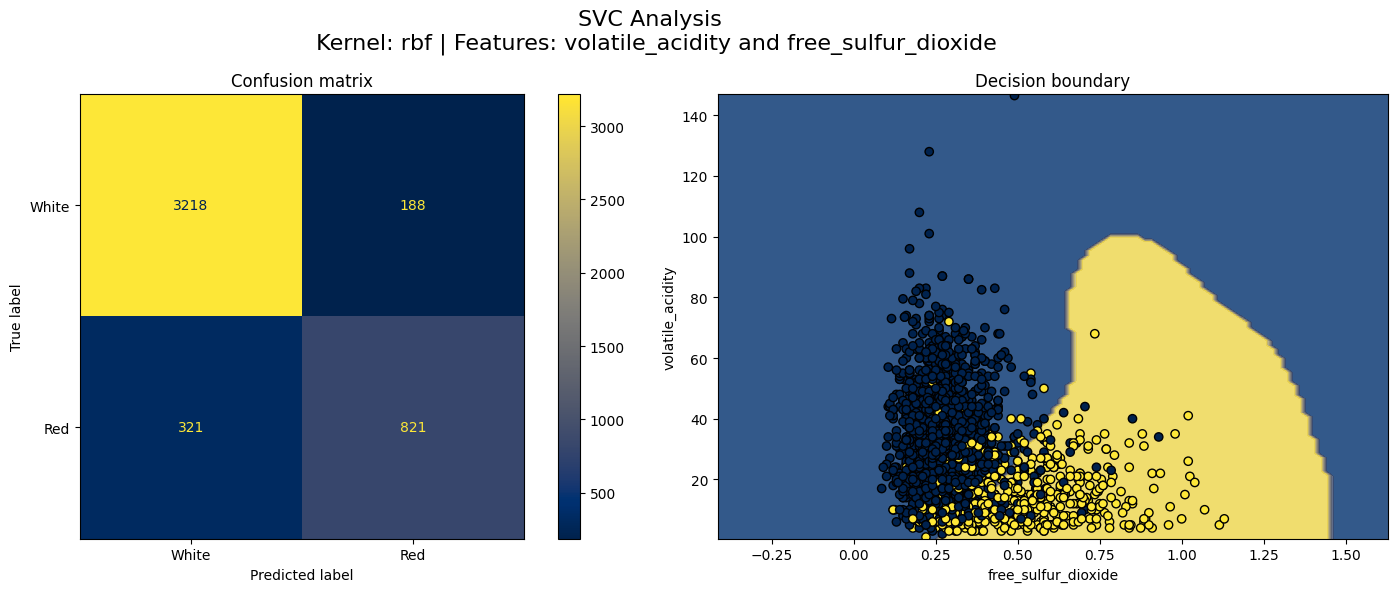

Classification report:
              precision    recall  f1-score   support

       white       0.91      0.94      0.93      3406
         red       0.81      0.72      0.76      1142

    accuracy                           0.89      4548
   macro avg       0.86      0.83      0.85      4548
weighted avg       0.89      0.89      0.89      4548


Kernel: poly
Training accuracy: 0.8845561826577732
Test accuracy: 0.8753298153034301 

Confusion Matrix:
[[3283  123]
 [ 444  698]]


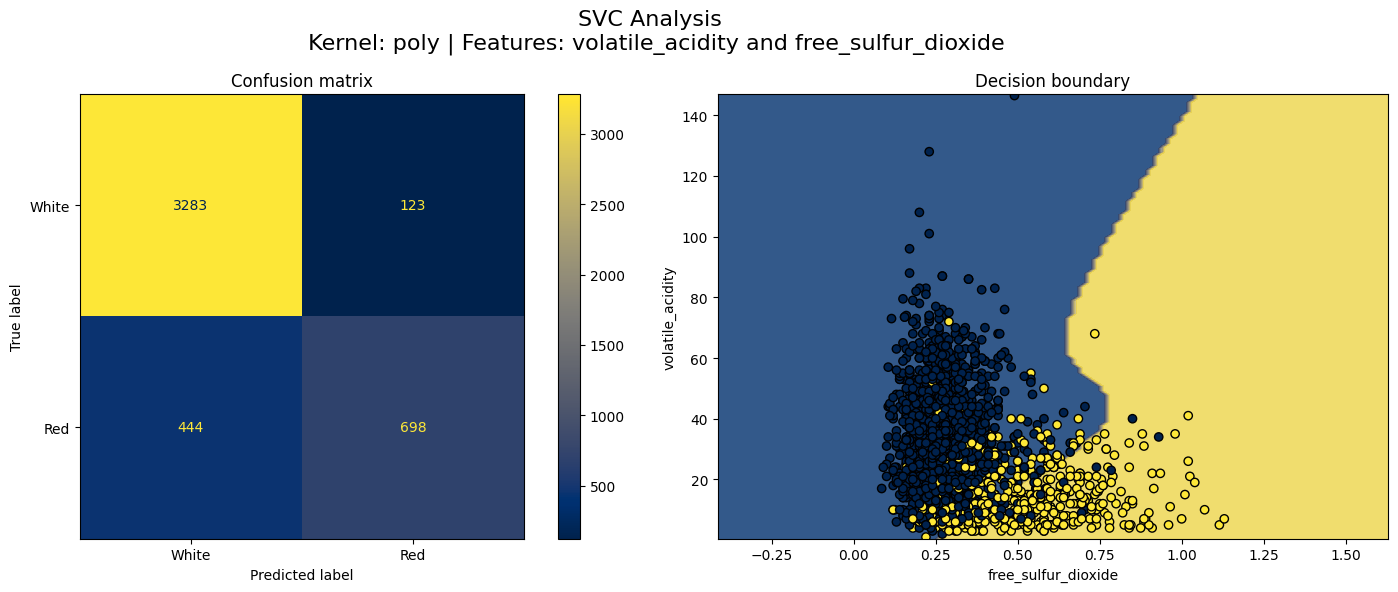

Classification report:
              precision    recall  f1-score   support

       white       0.88      0.96      0.92      3406
         red       0.85      0.61      0.71      1142

    accuracy                           0.88      4548
   macro avg       0.87      0.79      0.82      4548
weighted avg       0.87      0.88      0.87      4548


Kernel: sigmoid
Training accuracy: 0.797331965110313
Test accuracy: 0.7955145118733509 

Confusion Matrix:
[[2910  496]
 [ 434  708]]


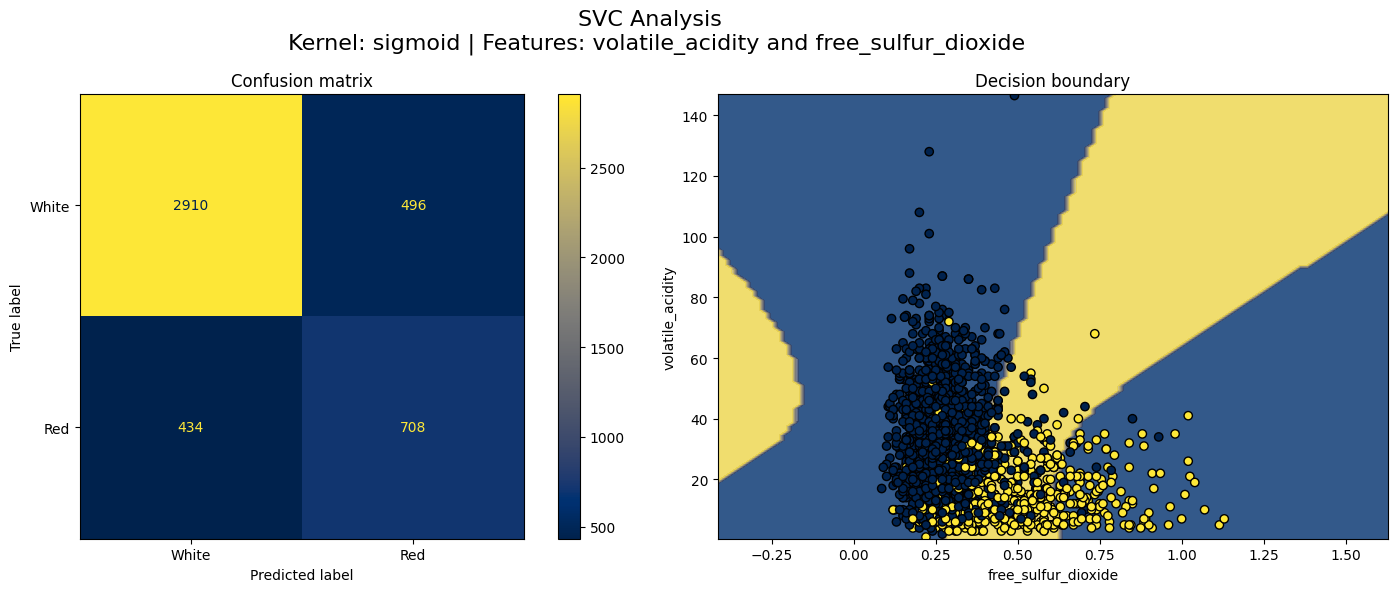

Classification report:
              precision    recall  f1-score   support

       white       0.87      0.85      0.86      3406
         red       0.59      0.62      0.60      1142

    accuracy                           0.80      4548
   macro avg       0.73      0.74      0.73      4548
weighted avg       0.80      0.80      0.80      4548


Accuracy summary:


,kernels,train_accuracies,test_accuracies
0,linear,0.897896,0.888742
1,rbf,0.897896,0.888083
2,poly,0.884556,0.875330
3,sigmoid,0.797332,0.795515



The best kernel based on test accuracy is: linear.


In [9]:
# lists to store accuracy metrics
kernels = []
train_accs = []
test_accs = []

# specifying feature columns to use (change this in the experiment)
col1 = 1 # volatile_acidity
col2 = 5 # free_sulfur_dioxide

feat1 = "volatile_acidity"
feat2 = "free_sulfur_dioxide"

# looping through all kernels to see which best classifies wine color
for kernel in ["linear", "rbf", "poly", "sigmoid"]:
    # SVC, selecting only volatile_acidity and free_sulfur_dioxide columns (columns 1 and 5, respectively)
    svc = make_pipeline(StandardScaler(), 
                        SVC(kernel=kernel)).fit(X_train[:, [col1, col2]], y_train.ravel())

    print(f"Kernel: {kernel}")

    # evaluating the classifier
    train_acc = svc.score(X_train[:, [col1, col2]], y_train.ravel())
    test_acc = svc.score(X_test[:, [col1, col2]], y_test.ravel())

    print(f"Training accuracy: {train_acc}")
    print(f"Test accuracy: {test_acc} ")
    print()

    # appending accuracies to their respective lists
    kernels.append(kernel)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # creating subplots (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))  

    # single title for both plots
    fig.suptitle(f"SVC Analysis \n Kernel: {kernel} | Features: {feat1} and {feat2}", fontsize=16)

    # showing the confusion matrix
    print("Confusion Matrix:")
    y_pred = svc.predict(X_test[:, [col1, col2]])
    print(confusion_matrix(y_test.ravel(), y_pred))
    ConfusionMatrixDisplay(confusion_matrix(y_test.ravel(), y_pred), display_labels = ["White", "Red"]).plot(ax=axes[0], cmap="cividis") 
    axes[0].set_title(f"Confusion matrix")
    DecisionBoundaryDisplay.from_estimator(svc, X_train[:, [col1, col2]], alpha=0.8, eps=0.5, response_method="predict", ax=axes[1], cmap="cividis")
    axes[1].scatter(X_train[:, col1], X_train[:, col2], c=y_train, edgecolors='k', cmap="cividis")
    axes[1].set_xlabel(f"{feat2}")
    axes[1].set_ylabel(f"{feat1}")
    axes[1].set_title(f"Decision boundary")

    plt.tight_layout()
    plt.show()

    print("Classification report:")
    print(classification_report(y_test.ravel(), y_pred, target_names={"white": 0, "red": 1}))

    print("================================================================================\n")

metrics_df = pd.DataFrame({
    "kernels" : kernels,
    "train_accuracies" : train_accs,
    "test_accuracies" : test_accs
})

print("Accuracy summary:")
display(metrics_df)

# finding the index of the maximum test accuracy
max_test_acc_ind = np.argmax(test_accs)

# getting the best kernel
best_kernel = kernels[max_test_acc_ind]

print(f"\nThe best kernel based on test accuracy is: {best_kernel}.")

Based on the experiment, if `volatile_acidity` and `free_sulfur_dioxide` are used as the features, the best classifier obtained is an SVC with a linear kernel, achieving a test accuracy of 0.888742. As for the other metrics, the classification report shows that, for an SVC with linear kernel, the best classifier achieved the following:
* Precision of 0.91 for white wine and 0.83 for red wine
* Recall of 0.95 for white wine and 0.71 for red wine
* F1-score of 0.93 for white wine and 0.76 for red wine  

The best SVC created in this experiment is better than the previous two best SVCs; however, it is still not better than the first best SVC, based on the metrics. This shows that `volatile_acidity` and `total_sulfur_dioxide` are still the best features to use when classifying wine color.

## Summary

* There are four experiments conducted corresponding to using four different pairs of features that (based on the EDA) are thought as best predictors of wine color: (1) `volatile_acidity` and `total_sulfur_dioxide`; (2) `volatile_acidity` and `citric_acid`; (3) `volatile_acidity` and `residual_sugar`; and (4) `volatile_acidity` and `free_sulfur_dioxide`. The choice of using only two "best" features out of all the features is for intepretability: with only two features, the decision boundary can be easily visualized. (However, it is also though that using only two features might affect the accuracy.)
* In each of the four experiments, an SVC model is fitted using four different kernels to check which best classifies wine color based on the two features used. The four kernels used are linear, rbf, poly, and sigmoid.
* A best SVC is selected in each of the experiments based on test accuracy. Other metrics such as precision, recall, and F1-score for the best SVC are reported via the classification report.
* Across the experiments, a uniform behavior has been observed with regards to the metrics (precision, recall, and F1-score) between white wine and red wine classification: the metrics are slightly higher for white wine classification than for red wine. This may be attributed to the higher number of white wine examples in the dataset, leading to better classification of such.
* In three out of four experiments, the linear kernel obtained the best test accuracy.
* After all the experiments, it has been found out that the best SVC (among all the best SVCs created) is the one that uses `volatile_acidity` and `total_sulfur_dioxide` as features and using a linear kernel (test accuracy of 95%). This suggests that these two features are the best predictors of wine color.
* Further work on classification of wine color using SVC is suggested, particularly to perform further hyperparameter tuning and feature selection. It would also be interesting to fit an SVC using three features, or even all features of the dataset.